Merging datasets with label

In [4]:
import pandas as pd
import numpy as np
import os

# read csv files
kor = pd.read_csv('/content/kor_shortend.csv')
neuro = pd.read_csv('/content/neuro_shortend.csv')

In [5]:
# print heads
print(kor.head())
print()
print(neuro.head())

       NEUT   INR  %NEUT       MCHC        WBC    eGFRCKD  eGFR-MDRD  \
0  4.850000   NaN  69.60  31.500000   6.970000  90.000000       60.0   
1  2.480000   NaN  51.45  31.750000   4.820000  26.000000       28.0   
2  6.050000  1.07  48.90  32.000000  12.380000  82.000000       60.0   
3       NaN   NaN    NaN        NaN        NaN  64.000000       60.0   
4  5.983333  0.89  67.70  34.333333   8.433333  79.666667       60.0   

          PLT       %IG   WPT  ...     %LYMPH    RBC   HCT       %EO  LYMPH  \
0  287.000000  0.300000   NaN  ...  22.700000  5.380  40.0  1.400000  1.580   
1  235.500000  0.300000   NaN  ...  24.250000  2.185  25.2  5.250000  1.165   
2  387.000000  0.600000  98.0  ...  40.700000  5.200  46.0  2.800000  5.040   
3         NaN       NaN   NaN  ...        NaN    NaN   NaN       NaN    NaN   
4  298.666667  0.466667  96.0  ...  22.666667  4.960  43.7  1.433333  1.720   

   patient_sex  patient_age examination_date    MPV      %MONO  
0            1        56.07

In [6]:
# przypisanie label do data sets
neuro['label'] = 1
kor['label'] = 0

In [11]:
# połączenie datasetów
aneurysm_concatted = pd.concat([kor, neuro], axis=0)

aneurysm_concatted.shape

(78162, 42)

In [13]:
counts = aneurysm_concatted['label'].value_counts()
percentages = aneurysm_concatted['label'].value_counts(normalize=True) * 100
for idx in counts.index:
    name = "Pozytywni (Tętniak [1])" if idx == 1 else "Nieoznaczeni (Unlabeled [0])"
    print(f"{name}: {counts[idx]} pacjentów ({percentages[idx]:.2f}%)")

Nieoznaczeni (Unlabeled [0]): 71546 pacjentów (91.54%)
Pozytywni (Tętniak [1]): 6616 pacjentów (8.46%)


In [18]:
# analiza korelacji ze zmienna 'label'

df_numeric = aneurysm_concatted.select_dtypes(include=['float64', 'int64'])
df_numeric = df_numeric.drop('patient_id', axis=1)

# 2. Obliczamy macierz korelacji Pearsona i wyciągamy tylko kolumnę 'label'
correlations = df_numeric.corr(method='pearson')['label'].drop('label')

# 3. Sortujemy wartości od największej do najmniejszej
correlations_sorted = correlations.sort_values(ascending=False)

print("--- TOP cechy skorelowane z tętniakiem (wartości dodatnie) ---")
print(correlations_sorted.head(10))

print("\n--- TOP cechy skorelowane z grupą nieoznaczoną (wartości ujemne) ---")
print(correlations_sorted.tail(10))

--- TOP cechy skorelowane z tętniakiem (wartości dodatnie) ---
WPT            0.095128
%EO            0.060911
MCV            0.052627
patient_sex    0.052167
eGFRCKD        0.050624
eGFR-MDRD      0.048604
%LYMPH         0.048455
EO             0.046640
MCH            0.026490
Na             0.021590
Name: label, dtype: float64

--- TOP cechy skorelowane z grupą nieoznaczoną (wartości ujemne) ---
PT      -0.034180
RDW     -0.035955
GLU     -0.037492
%IG     -0.037910
%NEUT   -0.045728
%BAZO   -0.051253
K       -0.071235
APTT    -0.074926
WAPTT   -0.075571
BAZO    -0.078264
Name: label, dtype: float64


/tmp/ipykernel_2783/3119768670.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations_sorted.values, y=correlations_sorted.index, palette=colors)


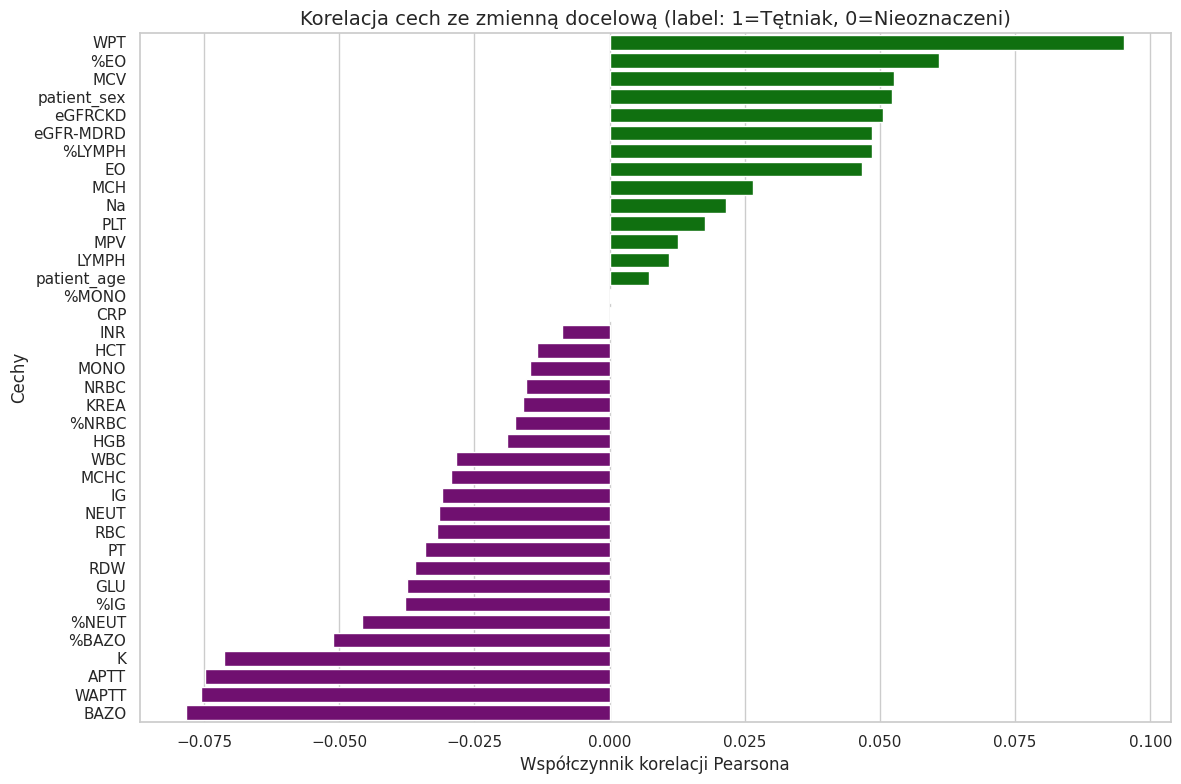

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

colors = ['green' if c > 0 else 'purple' for c in correlations_sorted.values]
sns.barplot(x=correlations_sorted.values, y=correlations_sorted.index, palette=colors)

plt.title('Korelacja cech ze zmienną docelową (label: 1=Tętniak, 0=Nieoznaczeni)', fontsize=14)
plt.xlabel('Współczynnik korelacji Pearsona', fontsize=12)
plt.ylabel('Cechy', fontsize=12)
plt.tight_layout()
plt.show()

* **Wartości dodatnie (np. > 0.15):** Im wyższa wartość danej cechy, tym większa szansa, że pacjent znajduje się w grupie z **tętniakiem (1)**.

* **Wartości ujemne (np. < -0.15):** Im wyższa wartość danej cechy, tym większa szansa, że pacjent znajduje się w puli **nieoznaczonej (0)**.

* **Wartości bliskie 0:** Cecha nie ma liniowego związku z tym, do której grupy trafił pacjent (może być bezużyteczna dla modelu liniowego, ale drzewa decyzyjne i tak mogą znaleźć w niej ukryte, nieliniowe wzorce).

In [23]:
# najmniej skorelowane parametry (najbliższe 0)
least_correlated = correlations.reindex(correlations.abs().sort_values().index)
print(least_correlated.head(10))

CRP            0.000295
%MONO          0.000338
patient_age    0.007210
INR           -0.008828
LYMPH          0.010945
MPV            0.012607
HCT           -0.013355
MONO          -0.014748
NRBC          -0.015431
KREA          -0.016038
Name: label, dtype: float64
